# 学生成绩预测：线性回归

这本 notebook 用线性回归预测 `exam_score`。

你可以把线性回归想象成：算法在找一个“加权公式”。例如：

`预测分数 = 基础分 + 学习时间的影响 + 睡眠的影响 - 娱乐时间的影响 + ...`

它的优点是容易解释；缺点是如果真实关系很弯曲、很复杂，它可能学得不够灵活。


In [1]:
# 导入常用工具。
# pandas 用来读取和整理表格数据；numpy 用来做一些数学计算。
from pathlib import Path
import numpy as np
import pandas as pd

# matplotlib 和 seaborn 用来画图。
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager
import seaborn as sns

# 让图表在 notebook 里直接显示，并设置一个比较清爽的风格。
%matplotlib inline
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.unicode_minus"] = False

# 中文图表标题需要中文字体。容器里通常有 Noto CJK，本机也可能有 PingFang SC。
preferred_fonts = ["Noto Sans CJK SC", "Noto Sans CJK JP", "PingFang SC", "Arial Unicode MS", "Microsoft YaHei"]
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
for font_name in preferred_fonts:
    if font_name in available_fonts:
        plt.rcParams["font.sans-serif"] = [font_name]
        print(f"图表中文字体: {font_name}")
        break
else:
    print("没有找到常见中文字体；如果图表中文显示为方块，可以在环境中安装 Noto CJK 字体。")

DATA_FILE = "student_habits_performance.csv"
TARGET_COLUMN = "exam_score"
ID_COLUMNS = ["student_id"]


def find_data_file(filename=DATA_FILE):
    """从当前目录一路向上找 data/ml_data/filename，兼容本机和容器。"""
    search_roots = [Path.cwd(), *Path.cwd().parents, Path("/workspace")]
    for base in search_roots:
        candidate = base / "data" / "ml_data" / filename
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"没有找到 {filename}，请确认它在 data/ml_data 目录下。")


data_path = find_data_file()
df = pd.read_csv(data_path)

print(f"数据文件: {data_path}")
print(f"数据大小: {df.shape[0]} 行, {df.shape[1]} 列")
df.head()


图表中文字体: Noto Sans CJK JP
数据文件: /workspace/data/ml_data/student_habits_performance.csv
数据大小: 1000 行, 16 列


,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


## 1. 分清楚“特征”和“目标”

- 目标 `y`：我们想预测的东西，这里是考试分数。
- 特征 `X`：用来做预测的信息，比如学习时间、睡眠时间、饮食质量。

`student_id` 只是编号，不代表学习习惯，所以不拿来预测。


In [2]:
# X 是所有可以用来预测的列。
# y 是考试分数，也就是模型要学会预测的答案。
X = df.drop(columns=[TARGET_COLUMN, *ID_COLUMNS], errors="ignore")
y = df[TARGET_COLUMN]

print("特征列数量:", X.shape[1])
print("目标列:", TARGET_COLUMN)
X.head()


特征列数量: 14
目标列: exam_score


,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation
0,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes
1,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No
2,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No
3,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes
4,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No


## 2. 区分数字列和文字列

机器学习模型只能直接处理数字。

- 数字列：可以直接进入模型，比如学习小时数。
- 文字列：需要先转换成 0/1，比如 `gender=Female`、`gender=Male`。这个过程叫 one-hot encoding。


In [3]:
# select_dtypes 可以按照数据类型挑选列。
numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["number"]).columns.tolist()

print("数字特征:", numeric_features)
print("类别特征:", categorical_features)


数字特征: ['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating']
类别特征: ['gender', 'part_time_job', 'diet_quality', 'parental_education_level', 'internet_quality', 'extracurricular_participation']


## 3. 切分训练集和测试集

我们不能只让模型“背答案”。

所以把数据分成两部分：

- 训练集：给模型学习。
- 测试集：模型没见过，用来检查它能不能预测新学生。


In [4]:
from sklearn.model_selection import train_test_split

# test_size=0.2 表示 20% 数据留作测试。
# random_state=42 让每次切分结果一样，方便复现。
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

print("训练集:", X_train.shape[0], "行")
print("测试集:", X_test.shape[0], "行")


训练集: 800 行
测试集: 200 行


## 4. 建立数据预处理和模型流水线

流水线的意思是：把“数据清理”和“模型训练”连在一起。

这里做三件事：

1. 数字列如果有缺失值，用中位数补上。
2. 数字列标准化，让不同单位的数字更容易比较。
3. 文字列转成 one-hot 数字列。


In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# 数字列处理：缺失值填中位数，再标准化。
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

# 类别列处理：缺失值填最常见类别，再转换成 one-hot。
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

# ColumnTransformer 负责把不同列交给不同处理方法。
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features),
    ]
)

# 最终流水线：先预处理，再训练线性回归模型。
linear_model = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", LinearRegression()),
    ]
)

linear_model


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different trans

## 5. 训练模型

`fit` 就是让模型从训练数据里学习规律。


In [6]:
# 模型会学习 X_train 和 y_train 之间的关系。
linear_model.fit(X_train, y_train)
print("线性回归模型训练完成")


线性回归模型训练完成


## 6. 在测试集上预测

`predict` 会让模型根据测试集特征猜分数。然后我们把“真实分数”和“预测分数”放在一起看。


In [7]:
# 预测测试集中每个学生的考试分数。
y_pred = linear_model.predict(X_test)

comparison = pd.DataFrame({
    "真实分数": y_test.values,
    "预测分数": y_pred,
    "误差": y_pred - y_test.values,
})
comparison.head(10)


,真实分数,预测分数,误差
0,64.2,66.200778,2.000778
1,72.7,75.120001,2.420001
2,79.0,78.058495,-0.941505
3,79.5,73.334655,-6.165345
4,58.2,61.019156,2.819156
5,53.4,54.058450,0.658450
6,70.8,75.573242,4.773242
7,62.5,55.042578,-7.457422
8,36.8,40.673725,3.873725
9,67.6,72.417729,4.817729


## 7. 用三个指标评价模型

- MAE：平均绝对误差。比如 MAE=4，表示平均差 4 分左右。
- RMSE：也表示误差，但对“大错”惩罚更重。
- R²：模型解释成绩变化的能力，越接近 1 越好。


In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

linear_metrics = pd.DataFrame([
    {"模型": "线性回归", "MAE": mae, "RMSE": rmse, "R²": r2}
])
linear_metrics


,模型,MAE,RMSE,R²
0,线性回归,4.192343,5.150974,0.896531


## 8. 画出真实分数和预测分数

如果模型预测得好，点会比较靠近斜线。斜线表示“预测分数 = 真实分数”。


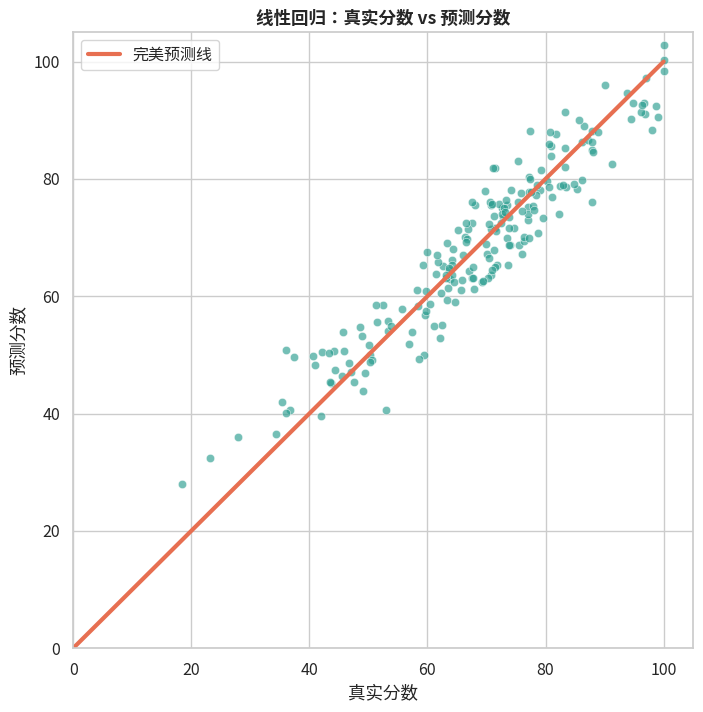

In [9]:
plt.figure(figsize=(8, 8))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.65, color="#2a9d8f")
plt.plot([0, 100], [0, 100], color="#e76f51", linewidth=3, label="完美预测线")
plt.title("线性回归：真实分数 vs 预测分数")
plt.xlabel("真实分数")
plt.ylabel("预测分数")
plt.xlim(0, 105)
plt.ylim(0, 105)
plt.legend()
plt.show()


## 9. 看哪些特征影响更大

线性回归的系数可以帮助解释模型。

系数为正：这个特征变大时，预测分数倾向增加。

系数为负：这个特征变大时，预测分数倾向降低。


/tmp/ipykernel_863/3789673779.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df, y="特征", x="系数", palette="vlag")


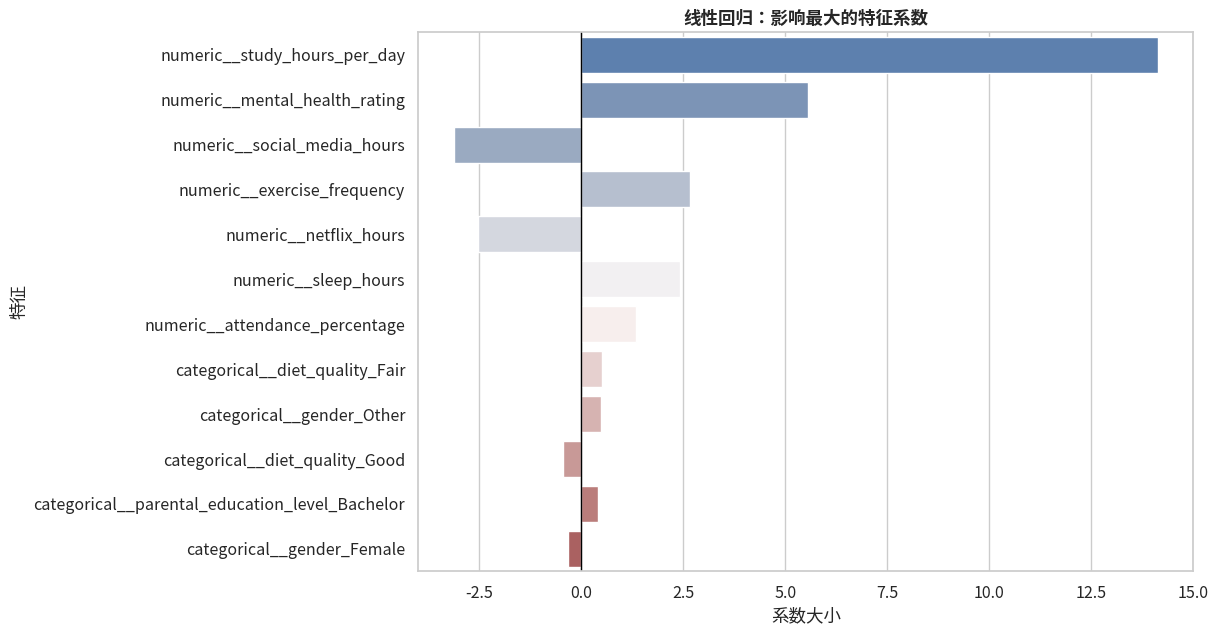

,特征,系数
1,numeric__study_hours_per_day,14.144790
7,numeric__mental_health_rating,5.565088
2,numeric__social_media_hours,-3.129732
6,numeric__exercise_frequency,2.656671
3,numeric__netflix_hours,-2.531563
5,numeric__sleep_hours,2.421865
4,numeric__attendance_percentage,1.349632
13,categorical__diet_quality_Fair,0.502625
10,categorical__gender_Other,0.491633
14,categorical__diet_quality_Good,-0.455348


In [10]:
# 取出 one-hot 之后的完整特征名和线性回归系数。
feature_names = linear_model.named_steps["preprocess"].get_feature_names_out()
coefficients = linear_model.named_steps["model"].coef_

coef_df = (
    pd.DataFrame({"特征": feature_names, "系数": coefficients})
    .assign(系数绝对值=lambda data: data["系数"].abs())
    .sort_values("系数绝对值", ascending=False)
    .head(12)
)

plt.figure(figsize=(10, 7))
sns.barplot(data=coef_df, y="特征", x="系数", palette="vlag")
plt.axvline(0, color="black", linewidth=1)
plt.title("线性回归：影响最大的特征系数")
plt.xlabel("系数大小")
plt.ylabel("特征")
plt.show()

coef_df.drop(columns="系数绝对值")


## 10. 和“只猜平均分”的简单方法对比

为了知道模型有没有真正学到东西，我们拿它和一个很笨的方法比：所有学生都预测成训练集平均分。

如果线性回归比这个方法误差小很多，说明模型确实学到了有用规律。


In [11]:
# 简单基线：不看任何特征，只把每个人都预测成训练集平均分。
baseline_pred = np.full_like(y_test, fill_value=y_train.mean(), dtype=float)

baseline_metrics = pd.DataFrame([
    {
        "模型": "只猜训练集平均分",
        "MAE": mean_absolute_error(y_test, baseline_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, baseline_pred)),
        "R²": r2_score(y_test, baseline_pred),
    },
    {
        "模型": "线性回归",
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2,
    },
])

baseline_metrics


,模型,MAE,RMSE,R²
0,只猜训练集平均分,12.380358,16.053180,-0.004974
1,线性回归,4.192343,5.150974,0.896531


## 小结

线性回归适合作为第一个模型，因为它好解释。这个数据集中，每天学习时间是最强信号，心理健康评分也很重要，社交媒体和 Netflix 时间整体偏负向。

下一本 notebook 会训练随机森林。随机森林更像“很多棵决策树一起投票”，有时能学到更复杂的关系。
